### 1. Import Libraries

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

### 2. Load the Dataset

In [2]:
df = pd.read_csv("heart_disease_uci.csv")
df.head

<bound method NDFrame.head of       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  False  

In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3+ KB


In [34]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num,target
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


### 3. Data Cleaning

In [40]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs           0
restecg       0
thalch       55
exang         0
oldpeak      62
slope         0
ca          611
thal          0
num           0
target        0
dtype: int64

In [41]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num',
       'target'],
      dtype='object')

In [42]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df[numeric_cols]

,id,age,trestbps,chol,thalch,oldpeak,ca,num,target
0,1,63,145.000000,233.0,150.000000,2.300000,0.000000,0,0
1,2,67,160.000000,286.0,108.000000,1.500000,3.000000,2,1
2,3,67,120.000000,229.0,129.000000,2.600000,2.000000,1,1
3,4,37,130.000000,250.0,187.000000,3.500000,0.000000,0,0
4,5,41,130.000000,204.0,172.000000,1.400000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...
915,916,54,127.000000,333.0,154.000000,0.000000,0.676375,1,1
916,917,62,132.132404,139.0,137.545665,0.878788,0.676375,0,0
917,918,55,122.000000,223.0,100.000000,0.000000,0.676375,2,1
918,919,58,132.132404,385.0,137.545665,0.878788,0.676375,0,0


In [43]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df = df.infer_objects()  


In [44]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

### 4. Exploratory Data Analysis (EDA)

#### Target Distribution

In [45]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num',
       'target'],
      dtype='object')


In [46]:
# 0 → No heart disease, 1 → Heart disease
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

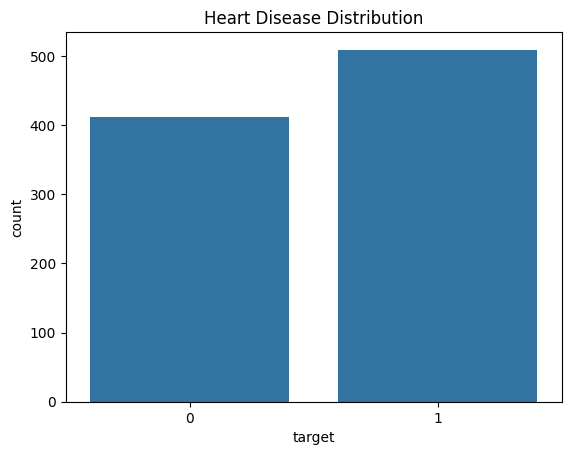

In [8]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

#### Correlation Heatmap

In [3]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

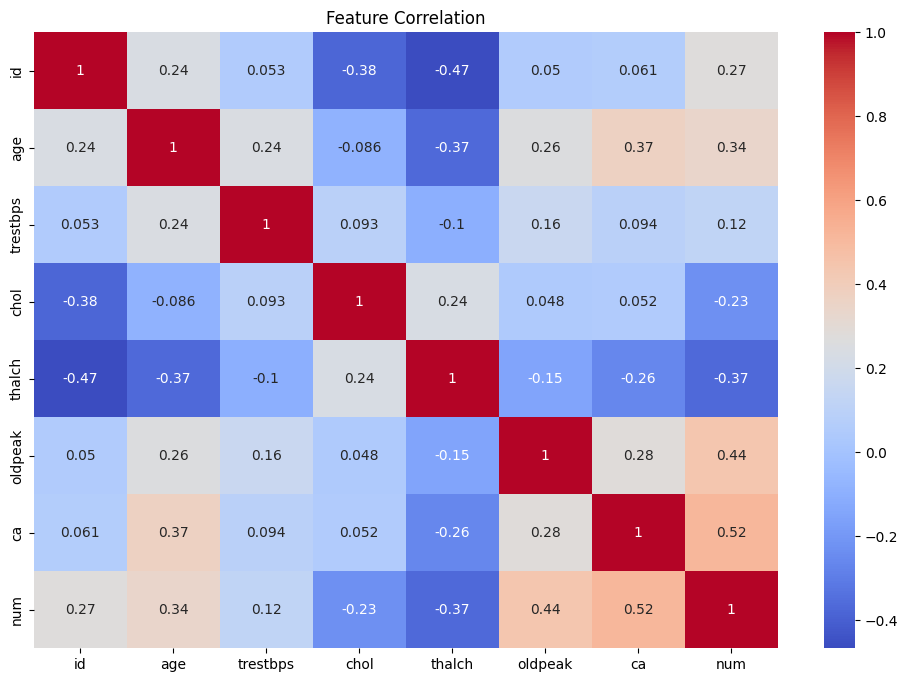

In [4]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

#### Age vs Heart Disease

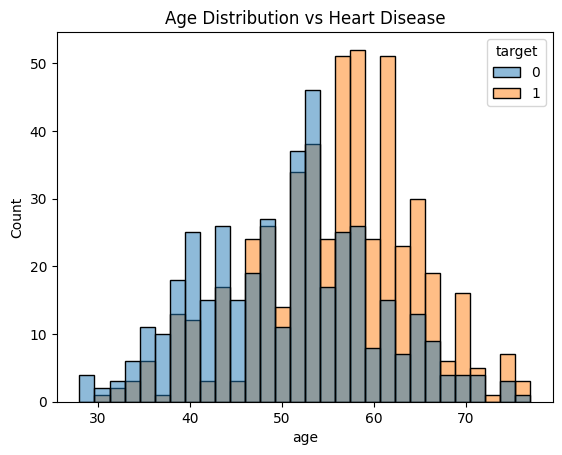

In [9]:
sns.histplot(data=df, x="age", hue="target", bins=30)
plt.title("Age Distribution vs Heart Disease")
plt.show()

### 5. Prepare Data for Modeling

In [28]:
# Separate features and target:
X = df.drop('target', axis=1)
y = df['target']

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [49]:
X = X.fillna(X.mean())

In [50]:
# Train-test split:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
# Scale features
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

### 6. Train Models

#### Logistic Regression

In [52]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#### Decision Tree

In [53]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### 7. Model Evaluation

#### Accuracy

In [54]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


#### Confusion Matrix

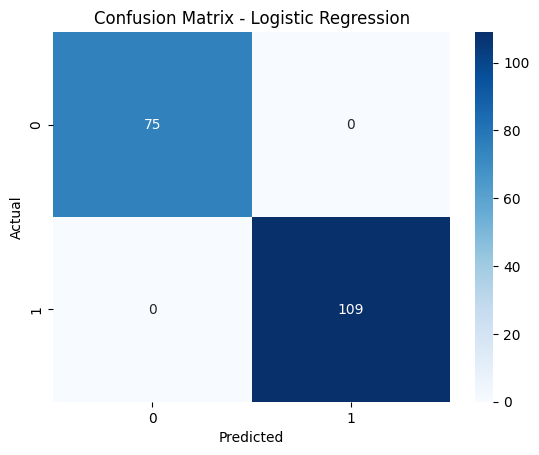

In [55]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


#### ROC Curve & AUC

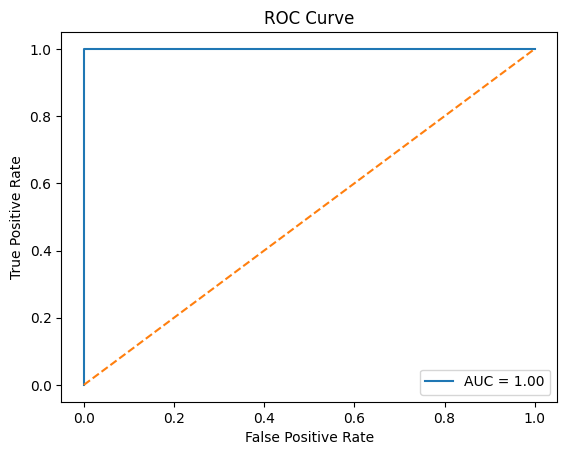

In [56]:
y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 8. Feature Importance

#### Logistic Regression Importance

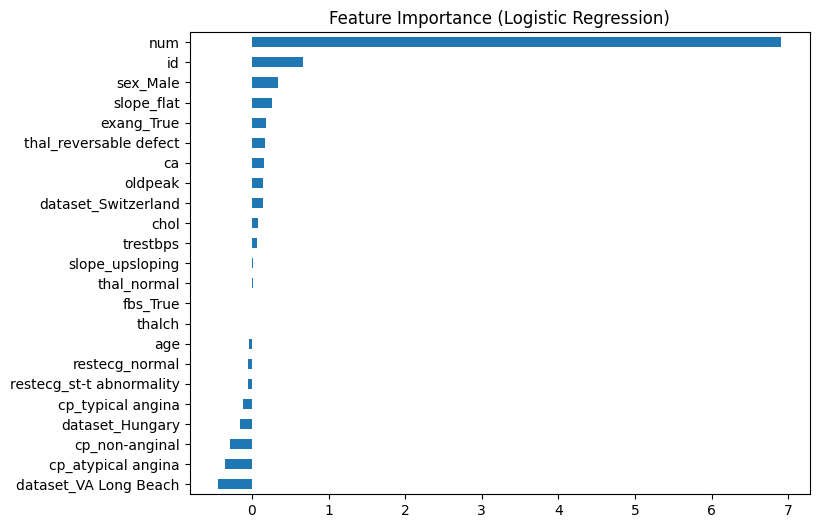

In [58]:
importance = pd.Series(lr.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.show()

#### Decision Tree Importance

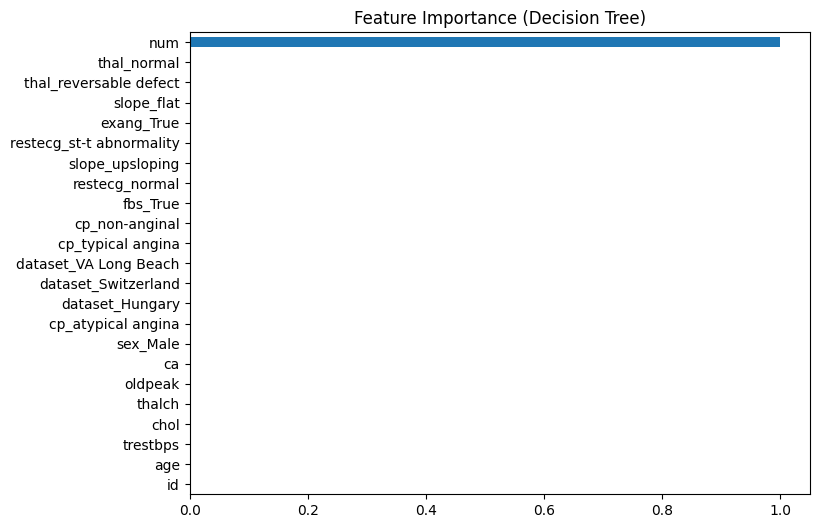

In [60]:
feat_importance = pd.Series(dt.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Decision Tree)")
plt.show()